# F08: Station surface winds
* Diurnal cycle plots of BARRA-2 surface winds vs station data for different regimes
* Barb and diurnal cycle plots of wind direction and speed barra vs station + function for circmean wind direction calculation

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import sys
import metpy
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
import pandas as pd
import os
import glob
from datetime import datetime
import seaborn as sns
from metpy.units import units
from shapely import Polygon
import geopandas as gpd
from scipy.stats import circmean
from sklearn.metrics import mean_squared_error
import pytz
from datetime import datetime, timedelta, time
import dask.dataframe as dd
import dask.distributed
import matplotlib.gridspec as gridspec
import windrose
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm

In [2]:
def UTC_to_LST(ds, timezone): # longitude
    ds = ds.copy()
    # Convert to pandas datetime in UTC
    time_objects_utc = pd.to_datetime(ds['time'].values).tz_localize('UTC')
    
    # Convert to local standard time using pytz
    local_timezone = pytz.timezone(timezone)
    time_objects_local = time_objects_utc.tz_convert(local_timezone).tz_localize(None)
    
    # Calculate longitude offset (in hours)
    # longitude_offset = timedelta(minutes=longitude*12/180) # /15)
    
    # # Local Solar Time = Local Standard Time + longitude offset
    # time_objects_solar = time_objects_local + longitude_offset
    
    # Assign back to ds['time'], remove timezone info if desired:
    ds['time'] = time_objects_local#.tz_localize(None)
    return ds

In [5]:
fp = '/g/data/w40/clv563/BoM_data/AWS-data-QLD.nc'
# station ID's can be found on the BoM website: http://www.bom.gov.au/catalogue/observations/about-weather-observations.shtml#maps
ds_stations = xr.open_dataset(fp, engine="h5netcdf")
ds_LST = UTC_to_LST(ds_stations,'Australia/Sydney')
jfma_data = ds_LST.sel(time=ds_LST.time.dt.month.isin([1,2,3,4]))

# cairns ID = 31011 --> station=21; townsville ID = 32040 --> station=30
ds_cairns_wd = jfma_data["wdir"].sel(station=21)* units("degrees")
ds_cairns_ws = jfma_data["wspd"].sel(station=21)* (1000/(60*60)) *  units("m/s")
ds_towns_wd = jfma_data["wdir"].sel(station=30)* units("degrees")
ds_towns_ws = jfma_data["wspd"].sel(station=30)* (1000/(60*60)) *  units("m/s")

In [6]:
def wind_masks(ds_wdir,ds_wdspd):
    calm_mask = xr.where(ds_wdspd==0*units('m/s'), np.nan, ds_wdspd)
    wdir_mask = xr.where(np.isnan(calm_mask), np.nan, ds_wdir)
    return wdir_mask,calm_mask

In [7]:
def calc_circ_mean_wd(ds, **kwargs):
    radian = np.deg2rad(ds)
    circmean_ds = circmean(radian,high=(2*np.pi),low=0,nan_policy='omit', **kwargs)
    return np.rad2deg(circmean_ds)

In [8]:
cairns_wd_mask, cairns_ws_masked = wind_masks(ds_cairns_wd,ds_cairns_ws)
towns_wd_mask, towns_ws_masked = wind_masks(ds_towns_wd,ds_towns_ws)

In [9]:
# hourly averages
cairns_wd = cairns_wd_mask.groupby('time.hour').reduce(calc_circ_mean_wd)
cairns_ws = cairns_ws_masked.groupby('time.hour').mean('time')
towns_wd = towns_wd_mask.groupby('time.hour').reduce(calc_circ_mean_wd)
towns_ws = towns_ws_masked.groupby('time.hour').mean('time')

In [10]:
# Open and regrid ETOPO2V2 dataset
NOAA_ETOPO2V2_ds = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
NOAA_ETOPO2V2_ds_slice = NOAA_ETOPO2V2_ds.sel(x=slice(140,155),y=slice(-22,-11))
lon = np.linspace(min(NOAA_ETOPO2V2_ds_slice['x'].data), max(NOAA_ETOPO2V2_ds_slice['x'].data), len(NOAA_ETOPO2V2_ds_slice['x'].data))
lat = np.linspace(min(NOAA_ETOPO2V2_ds_slice['y'].data), max(NOAA_ETOPO2V2_ds_slice['y'].data), len(NOAA_ETOPO2V2_ds_slice['y'].data))
lon, lat = np.meshgrid(lon, lat)
topo = NOAA_ETOPO2V2_ds_slice['z'].data

In [44]:
def plot_windrose_map(cairns_wd,cairns_ws,towns_wd,towns_ws,main_ax, hour, letterlabel, cbar: bool=None,legend: bool=None):
    proj = ccrs.PlateCarree()
    main_ax.set_extent([144, 149, -21.5, -14], crs=proj)
    main_ax.coastlines()

    cairns_wd_hour = cairns_wd.sel(time=cairns_wd.time.dt.hour.isin(hour))
    cairns_ws_hour = cairns_ws.sel(time=cairns_ws.time.dt.hour.isin(hour))
    towns_wd_hour = towns_wd.sel(time=towns_wd.time.dt.hour.isin(hour))
    towns_ws_hour = towns_ws.sel(time=towns_ws.time.dt.hour.isin(hour))

    fig = main_ax.figure
    sns.set_style('white')
    color = ['#084594', '#2171b5', '#4292c6', '#6baed6', '#9ecae1', '#c6dbef', '#deebf7', '#f7fcb9','#d9f0a3','#addd8e',
            '#78c679','#31a354','#006837','darkslategrey','#d7ccca']
    levels = [-800, -500, -300, -200, -100, -50, -25, 0, 50, 100, 200, 300, 500, 800, 1000]
    cs = main_ax.contourf(lon,lat,topo,levels=levels,extend="both",colors=color,alpha=0.75)
    if cbar:
        cbar_ax = fig.add_axes([0.9, 0.58, 0.02, 0.3]) #([left, bottom, width, height])
        cb = fig.colorbar(cs, cax=cbar_ax)
        cb.set_label("Meters",fontsize=15)

    # Coordinates of the station we were measuring windspeed
    towns_lon, towns_lat = (146.77,-19.25)
    cairns_lon, cairns_lat = (145.75,-16.87)

    size = 2.5
    sns.set_theme(style="dark")
    # Inset axes with a fixed size
    wrax_towns = inset_axes(
        main_ax,
        width=size,  # size in inches
        height=size,  # size in inches
        loc="center",  # center bbox at given position
        bbox_to_anchor=(towns_lon, towns_lat),  # position of the axe
        bbox_transform=main_ax.transData,  # use data coordinate (not axe coordinate)
        axes_class=windrose.WindroseAxes,  # specify the class of the axe
    )
    wrax_cairns = inset_axes(
        main_ax,
        width=size,  # size in inches
        height=size,  # size in inches
        loc="center",  # center bbox at given position
        bbox_to_anchor=(cairns_lon, cairns_lat),  # position of the axe
        bbox_transform=main_ax.transData,  # use data coordinate (not axe coordinate)
        axes_class=windrose.WindroseAxes,  # specify the class of the axe
    )

    # set transparency of wind rose figure
    wrax_cairns.patch.set_alpha(0.3)
    wrax_towns.patch.set_alpha(0.3)

    # # create bar plots
    barT = wrax_towns.bar(towns_wd_hour, towns_ws_hour,normed=True,bins=[0,2,4,6,8,10],opening=1,cmap=cm.plasma,ec='black',lw=0.1)
    barC = wrax_cairns.bar(cairns_wd_hour, cairns_ws_hour,normed=True,bins=[0,2,4,6,8,10],opening=1,cmap=cm.plasma,ec='black',lw=0.1)
    for ax, ec in zip([wrax_towns, wrax_cairns], ['none', 'none']):
        for bar in ax.patches:
            bar.set_edgecolor(ec)
    if legend:
        l=wrax_cairns.set_legend(
            title="m s$^{-1}$",
            bbox_to_anchor=(1.9, -1.3),fontsize=18,title_fontsize=20) #(2.2,-1.2)) # #bbox_to_anchor=(4, 0.65, 1, 1)) #
        for text, label in zip(l.get_texts(), ['[0-2)', '[2-4)', '[4-6)', '[6-8)', '[8-10)', '[10-15)','>15']):
            text.set_text(label)
            text.set_fontsize(12)

    
    for ax in [wrax_towns, wrax_cairns]:
        ax.tick_params(colors='black',labelbottom=False)#labelleft=False
##############
        ax.set_rmax(30)
        ax.spines['polar'].set_color('black')
        ax.set_yticks([10, 20, 30])
        ax.set_yticklabels(['10%', '20%', '30%'], fontsize=12)
        # ax.set_thetagrids([0, 90, 180, 270])
##############
    sns.set_style('white')
    # other plot details
    main_ax.set_title(str(hour)+" LT",fontsize=20,)
    main_ax.set_title(str(letterlabel),loc='left',fontsize=15,)
    main_ax.set_xticks([144,145,146,147,148,149])
    main_ax.set_xticklabels([144,145,146,147,148,149])
    main_ax.set_yticks([-21,-20,-19,-18,-17,-16,-15,-14])
    main_ax.set_yticklabels([-21,-20,-19,-18,-17,-16,-15,-14])
    main_ax.set_xlabel("Longitude",fontsize=15)
    main_ax.set_ylabel("Latitude",fontsize=15)

In [49]:
def plot_diurnal_cycles(hour_morning,hour_afternoon,windrose_cbar,windrose_legend,wd_station1,wd_station2,ws_station1,ws_station2,title_ax1: str = 'Cairns diurnal wind speed and direction',
                        title_ax3: str = 'Townsville diurnal wind speed and direction',color_obs: str = 'black'):
    fig = plt.figure(figsize=[15,15])
    
    gs = gridspec.GridSpec(4, 2, height_ratios=[1,0.12,0.3, 0.1],hspace=0)  # Second subplot half the height
    ax1 = fig.add_subplot(gs[2,0])
    ax2 = fig.add_subplot(gs[3,0])
    ax3 = fig.add_subplot(gs[2,1])
    ax4 = fig.add_subplot(gs[3,1])

    # Main windrose map panel
    ax5 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    plot_windrose_map(cairns_wd_mask,cairns_ws_masked,towns_wd_mask,towns_ws_masked,ax5,hour_morning,"(a)")
    ax6 = fig.add_subplot(gs[0,1], projection=ccrs.PlateCarree())
    plot_windrose_map(cairns_wd_mask,cairns_ws_masked,towns_wd_mask,towns_ws_masked,ax6,hour_afternoon,"(b)",cbar=windrose_cbar,legend=windrose_legend)
    
    # sns.set_theme(style="darkgrid")
    # setup axes for wind speed and wind barbs
    for ax in [ax1,ax2,ax3,ax4]:
        ax.set_xlim(0,23)
    for ax in [ax1,ax3]:
        ax.set_xticks(np.arange(0,23,3))
        ax.set_xticklabels([])
        ax.set_yticks([3,4,5,6,7])
        ax.set_ylim(3,7)
    for ax in [ax2,ax4]:
        ax.set_xticks(np.arange(0,23,3))
        ax.set_xticklabels(["00","03","06","09","12","15","18","21"],fontsize=15)
        ax.set_yticks([])
        ax.set_xlabel('Hour (LT)',fontsize=15)
        ax.set_facecolor('white')
    ax1.set_yticklabels(['3','4','5','6','7'],fontsize=15)
    ax3.set_yticklabels([])
    ax1.plot(np.arange(0,24,1),ws_station1,color=color_obs,linewidth=3,marker="o")
    ax3.plot(np.arange(0,24,1),ws_station2,color=color_obs,linewidth=3,marker="o")
    ax1.set_title(title_ax1,fontsize=18)
    ax1.set_title("(c)", loc="left", fontsize=15)
    ax3.set_title(title_ax3,fontsize=18)
    ax3.set_title("(d)", loc="left", fontsize=15)
    ax1.set_ylabel('m s$^{-1}$',fontsize=15)
    
    wd_degrees_station1 = wd_station1 + 180 # 180 is added so that the direction plotted for barbs is the direction "from"
    wd_degrees_station2 = wd_station2 + 180
    wd_radians_station1 = np.radians(90 - wd_degrees_station1)
    wd_radians_station2 = np.radians(90 - wd_degrees_station2)
    ax2.barbs(range(len(wd_degrees_station1)), [-1] * len(wd_degrees_station1), ws_station1 * np.cos(wd_radians_station1), 
              ws_station1 * np.sin(wd_radians_station1),
              barb_increments=dict(half=2, full=4, flag=20), length=7,pivot='middle',flip_barb=True,color=color_obs,zorder=3)
    ax4.barbs(range(len(wd_degrees_station2)), [-1] * len(wd_degrees_station2), ws_station2 * np.cos(wd_radians_station2), 
              ws_station2 * np.sin(wd_radians_station2),
              barb_increments=dict(half=2, full=4, flag=20), length=7,pivot='middle',flip_barb=True,color=color_obs,zorder=3)
    plt.subplots_adjust(hspace=0.5,wspace=0.07)
    fig.savefig('/home/563/ac9768/GBR/scripts/Paper_figures/f08v2.png', bbox_inches='tight', dpi=300)
    plt.show()

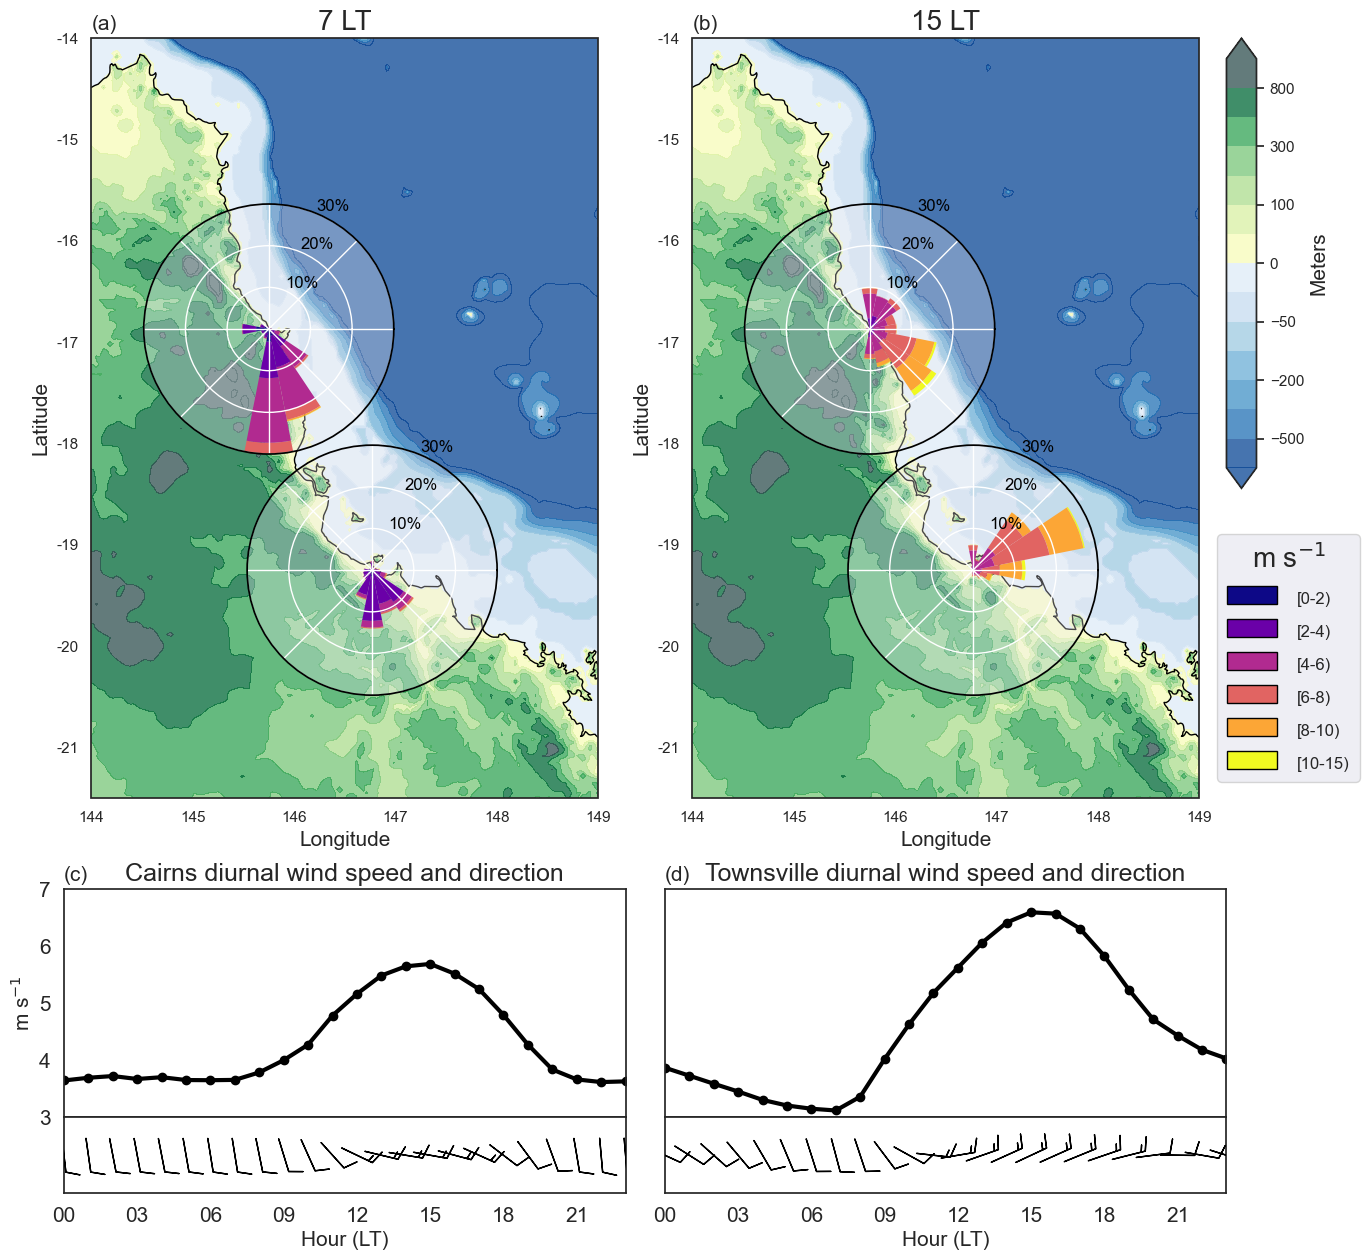

In [50]:
sns.set_style('white')
plot_diurnal_cycles(7,15,True,True,cairns_wd.values,towns_wd.values,cairns_ws.values,towns_ws.values,)
